# Figure 6 — Detection performance (injection truth + MER catalogue)

Combined detection-performance figure for the CenterNet head on the **frozen** foundation
fused 10-band bottleneck (`vis_peak`, round-1, 200 tiles), evaluated on the 16 held-out
tiles at threshold $0.30$ throughout.

- **(a)** Point-source completeness vs VIS magnitude. Solid curves are catalogue-independent
  **source-recycling injection** (all 10 bands / VIS only / NISP only); the dashed curve is
  recovery of the **real clean-MER catalogue**; the grey histogram (right axis) is the MER
  VIS-magnitude distribution — i.e. where the existing catalogue's sources actually lie. The
  10-band 50% depth (VIS 26.0) reaches past the bulk of the MER distribution, and the shaded
  gap to VIS-only is the $\approx0.4$ mag bought by band fusion.
- **(b)** Completeness vs **measured** VIS aperture S/N (no magnitude zeropoint).
- **(c)** Operating point: completeness (VIS<24.5) and purity vs detection threshold; the
  $0.30$ working point is marked. Purity is measured against the full MER catalogue and is a
  conservative floor (some unmatched detections are real sources MER missed).

This assembles the two cached evals (`_fig6_injection_cache.pkl` from the injection run,
`_fig7_completeness_cache.pkl` from the catalogue/S-N/threshold sweep). Saves
`paper/figures/fig6_detection_performance.png`.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root(); NB=Path.cwd()
INJ_CACHE=NB/'_fig6_injection_cache.pkl'      # produced by the injection eval
CMP_CACHE=NB/'_fig7_completeness_cache.pkl'    # produced by the catalogue / S-N / threshold sweep
OUT=REPO/'paper'/'figures'/'fig6_detection_performance.png'
for p in (INJ_CACHE,CMP_CACHE):
    assert p.exists(), f'missing cache: {p}  (run the injection / completeness notebook first)'
print('injection cache:',INJ_CACHE.name,'| completeness cache:',CMP_CACHE.name)

injection cache: _fig6_injection_cache.pkl | completeness cache: _fig7_completeness_cache.pkl


saved -> /home/shemmati/Work/Projects/JAISP/paper/figures/fig6_detection_performance.png
depth all=25.99 vis=25.56 | S/N50=NA | purity@0.30=55.8%


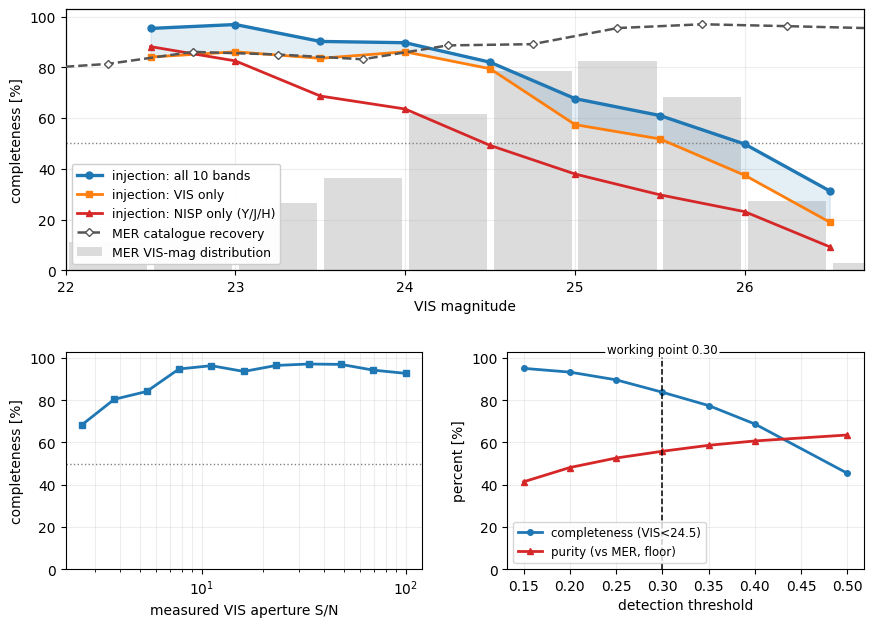

In [2]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

inj=pickle.load(open(INJ_CACHE,'rb')); cmp=pickle.load(open(CMP_CACHE,'rb'))
M=np.array(inj['mags']); rec=inj['rec']
def icurve(mode): return np.array([100*rec[mode][m][0]/max(rec[mode][m][1],1) for m in inj['mags']])
c_all,c_vis,c_nisp=icurve('all'),icurve('vis'),icurve('nisp')
def d50(comp):
    for i in range(len(M)-1):
        if comp[i]>=50>=comp[i+1]:
            t=(50-comp[i])/((comp[i+1]-comp[i]) or -1e-9); return M[i]+t*(M[i+1]-M[i])
    return M[-1] if comp[-1]>=50 else M[0]
dep_all,dep_vis=d50(c_all),d50(c_vis)

# MER catalogue recovery curve + magnitude distribution (from completeness cache)
mag,hit,snr=cmp['rec_mag'],cmp['rec_hit'].astype(float),cmp['rec_snr']
def binned(x,y,edges,nmin=20,geom=False):
    cen,val=[],[]
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(x>=lo)&(x<hi)&np.isfinite(x)
        if m.sum()<nmin: continue
        cen.append(np.sqrt(lo*hi) if geom else 0.5*(lo+hi)); val.append(100*y[m].mean())
    return np.array(cen),np.array(val)
medg=np.arange(19.5,27.01,0.5)
mc,mv=binned(mag,hit,medg,nmin=20)

CA,CV,CN,CM,CS,CP='#1f77b4','#ff7f0e','#d62728','#555555','#1f77b4','#d62728'
fig=plt.figure(figsize=(9.5,6.4))
gs=GridSpec(2,2,height_ratios=[1.2,1.0],hspace=0.34,wspace=0.24,
            left=0.085,right=0.925,top=0.97,bottom=0.095)

# ---- (a) completeness vs VIS mag : injection + MER recovery + MER mag histogram
ax=fig.add_subplot(gs[0,:])
axh=ax.twinx()
hcnt,hedg=np.histogram(mag[np.isfinite(mag)],bins=medg)
hfrac=hcnt/max(hcnt.sum(),1)
axh.bar(0.5*(hedg[:-1]+hedg[1:]),hfrac,width=0.46,color='0.7',alpha=0.45,zorder=0)
axh.set_yticks([]); axh.set_ylim(0,hfrac.max()*1.25)

ax.set_zorder(axh.get_zorder()+1); ax.patch.set_visible(False)
ax.plot(M,c_all,'-o',color=CA,lw=2.4,ms=5,label='injection: all 10 bands',zorder=5)
ax.plot(M,c_vis,'-s',color=CV,lw=2.0,ms=4,label='injection: VIS only',zorder=5)
ax.plot(M,c_nisp,'-^',color=CN,lw=2.0,ms=5,label='injection: NISP only (Y/J/H)',zorder=5)
ax.fill_between(M,c_vis,c_all,color=CA,alpha=0.12,zorder=2)
ax.plot(mc,mv,'--D',color=CM,lw=1.8,ms=4,mfc='white',label='MER catalogue recovery',zorder=5)
ax.axhline(50,color='gray',ls=':',lw=1)
ax.set_xlabel('VIS magnitude'); ax.set_ylabel('completeness [%]')
ax.set_xlim(22.0,26.7); ax.set_ylim(0,103)
h,l=ax.get_legend_handles_labels()
h.append(Patch(facecolor='0.7',alpha=0.45)); l.append('MER VIS-mag distribution')
ax.legend(h,l,fontsize=9,loc='lower left',framealpha=0.95,ncol=1)
ax.grid(alpha=0.22)

# ---- (b) completeness vs measured VIS S/N
ax=fig.add_subplot(gs[1,0])
sedg=np.logspace(np.log10(1.5),np.log10(120),13); sc,sv=binned(snr,hit,sedg,nmin=20,geom=True)
ax.plot(sc,sv,'-s',color=CS,lw=2,ms=4)
ax.axhline(50,color='gray',ls=':',lw=1)
def cross(level,xc,yc):
    for i in range(len(xc)-1):
        if yc[i]>=level>=yc[i+1]:
            t=(level-yc[i])/((yc[i+1]-yc[i]) or -1e-9); return xc[i]+t*(xc[i+1]-xc[i])
    return None
s50=cross(50,sc,sv)
if s50: ax.axvline(s50,color=CS,ls='--',lw=1.2); ax.text(s50*1.06,8,f'50% at S/N={s50:.1f}',color=CS,fontsize=9)
ax.set_xscale('log'); ax.set_xlabel('measured VIS aperture S/N'); ax.set_ylabel('completeness [%]'); ax.set_ylim(0,103)
ax.grid(alpha=0.22,which='both')

# ---- (c) operating point: completeness & purity vs threshold
ax=fig.add_subplot(gs[1,1])
confs=np.array(cmp['confs']); comp=np.array([100*cmp['comp_curve'][k] for k in cmp['confs']])
pur =np.array([100*cmp['pur_curve'][k] for k in cmp['confs']]); cmain=cmp['conf_main']
ax.plot(confs,comp,'-o',color=CA,lw=2,ms=4,label=f'completeness (VIS<{cmp["comp_maglim"]:.1f})')
ax.plot(confs,pur ,'-^',color=CP,lw=2,ms=4,label='purity (vs MER, floor)')
ax.axvline(cmain,color='k',ls='--',lw=1.1)
ax.text(cmain,101,f'working point {cmain:.2f}',fontsize=8.5,ha='center',va='bottom',
        bbox=dict(boxstyle='round,pad=0.15',fc='white',ec='none'))
ax.set_xlabel('detection threshold'); ax.set_ylabel('percent [%]'); ax.set_ylim(0,103)
ax.legend(fontsize=8.5,loc='lower left'); ax.grid(alpha=0.22)

fig.savefig(OUT,dpi=300,bbox_inches='tight',facecolor='white')
print('saved ->',OUT)
print('depth all=%.2f vis=%.2f | S/N50=%s | purity@%.2f=%.1f%%'%(
      dep_all,dep_vis,('%.1f'%s50 if s50 else 'NA'),cmain,100*cmp['pur_curve'][cmain]))
plt.show()